In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from math import log2, ceil, floor

PATH = "./data/cells_report32.csv";
original_dim = (1000, 1000, 1000)
BRICK_SIZE = 32

In [5]:
csv = pd.read_csv(PATH)
for col in csv.columns:
    csv[col] = csv[col].astype(int)

ALL_CODES = ["PARENT", "NEIGHBORX", "NEIGHBORY", "NEIGHBORZ", "PALETTE_D", "PALETTE_ADV", "PALETTE_LAST", "sPARENT", "sNEIGHBORX", "sNEIGHBORY", "sNEIGHBORZ", "sPALETTE_D", "sPALETTE_ADV", "sPALETTE_LAST"]
for name in ["PARENT", "NEIGHBORX", "NEIGHBORY", "NEIGHBORZ", "PALETTE_D", "PALETTE_ADV", "PALETTE_LAST"]:
    csv["t" + name] = csv[name] + csv["s" + name]
csv["palette_duplicates"] = csv["palette_size"] - csv["unique_ids"]
csv["encoding_size"] = csv["total_size"] - csv["palette_size"] - (2*log2(BRICK_SIZE)+1) - 1   #total size - palette - header - brickstart buffer entry
csv["STOP"] = csv["sPARENT"] + csv["sNEIGHBORX"] + csv["sNEIGHBORY"] + csv["sNEIGHBORZ"] + csv["sPALETTE_D"] + csv["sPALETTE_ADV"] + csv["sPALETTE_LAST"];
csv.head(8)

,NEIGHBORX,NEIGHBORY,NEIGHBORZ,PALETTE_ADV,PALETTE_D,PALETTE_LAST,PARENT,__unused__,brick_visibility,brick_x,...,tPARENT,tNEIGHBORX,tNEIGHBORY,tNEIGHBORZ,tPALETTE_D,tPALETTE_ADV,tPALETTE_LAST,palette_duplicates,encoding_size,STOP
0,3102,1248,424,144,50,67,9081,0,2,0,...,10541,3348,1357,449,51,149,74,64,839.0,1853
1,2866,1212,417,133,58,67,8526,0,2,1,...,10005,3129,1312,445,61,139,70,59,809.0,1882
2,2948,1209,457,130,69,91,8709,0,2,2,...,10275,3170,1290,489,74,134,97,52,834.0,1916
3,3109,1221,428,147,48,73,9165,0,2,3,...,10717,3334,1311,477,51,149,82,64,846.0,1930
4,3054,1110,435,139,43,52,8950,0,2,4,...,10520,3249,1192,458,43,144,67,60,809.0,1890
5,3046,1248,391,133,38,43,8841,0,2,5,...,10336,3316,1343,426,40,138,50,58,818.0,1909
6,2874,1185,442,120,49,74,8959,0,2,6,...,10476,3114,1280,475,51,126,87,41,816.0,1906
7,2953,1276,495,133,49,60,8894,0,2,7,...,10471,3168,1358,528,51,135,66,49,833.0,1917


In [3]:
# ToDo: why does the sorting not work?
sorted = csv.sort_values(by="total_size", ascending=True)
for i in range(1, sorted.shape[0]):
    if(sorted["total_size"][i] < sorted["total_size"][i-1]):
        print(str(sorted["total_size"][i]) + " is < " + str(sorted["total_size"][i-1]) + " csv " + str(csv["total_size"][i]))
        break

960 is < 1000 csv 960


In [4]:
# header_size = int(2*log2(BRICK_SIZE)+1)
# print("Header size: " + str(header_size))
# print("Avg. Encoding size (#uint32): " + str(csv["encoding_size"].mean()))
# print("Avg. Palette entry count: " + str(csv["palette_size"].mean()))


# sorted = csv.sort_values(by="total_size", ascending=True)
# avg_index = sorted[sorted["total_size"].gt(sorted["total_size"].mean())].index[0]

# encoding = [sorted["encoding_size"][0], sorted["encoding_size"][avg_index], sorted["encoding_size"][sorted.shape[0]-1]]
# total = [sorted["total_size"][0], sorted["total_size"][avg_index], sorted["total_size"][sorted.shape[0]-1]]
# palette = [sorted["palette_size"][0], sorted["palette_size"][avg_index], sorted["palette_size"][sorted.shape[0]-1]]
# header = [header_size, header_size, header_size]

# labels = ['Min', 'Avg', 'Max']
# width = 0.35       # the width of the bars: can also be len(x) sequence

# fig, ax = plt.subplots()

# ax.bar(labels, header, width, label='Header')
# ax.bar(labels, encoding, width, bottom=header, label='Encoding')
# #ax.bar(x=range(0, len(csv["total_size"])), height=csv.sort_values(by=["total_size"], ascending=True)["total_size"], width=width, label='Total')
# ax.bar(labels, palette, width, bottom=[x+y for x, y in zip(header, encoding)], label='Palette')

# ax.set_ylabel('#uint32')
# ax.set_title('Memory used per ' + str(BRICK_SIZE) + '³ Brick')
# ax.legend()

# plt.show()


In [5]:
#big01 = np.array([34930163,12527410,7084352,3807529,373842,2351883,600053,6143,292180856,87557797,31368572,10242931,641935,1292699,771307,25712])
#mouse = np.array([4.5e-5 , 1.97e-5 , 1.6e-5, 1.97e-5, 4.0e-5, 2.4e-5, 1.9e-5, 2.41e-5 , 1.85e-5, 3.3e-5 ])

In [9]:
# compute some general information about this compression
print("Total size: " + str(csv["total_size"].sum()) + " (" + str(csv["total_size"].sum() / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.) + "% compression)")
rle_size = csv["total_size"].sum() + csv["rle_4bit_reduction"].sum()//8
print("approx. total size Without RLE: " + str(rle_size) + " (" + str(rle_size / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.) + "% compression)")
print("average number of duplicate palette entries: " + str(csv["palette_duplicates"].mean()))
worst_row_id = csv["total_size"].idxmax()
print("Worst brick: " + str(csv["brick_x"][worst_row_id]) + "," + str(csv["brick_y"][worst_row_id]) + "," + str(csv["brick_z"][worst_row_id]) + " " + str(csv["total_size"].max()*4/1024) + " KB (" + str(csv["total_size"].max()/(BRICK_SIZE**3) * 100.) + "% compression) with " + str(csv["unique_ids"][worst_row_id]) + " unique ids and " + str(csv["palette_duplicates"][worst_row_id]) + " palette duplicates:")

print(csv["total_size"].mean())
print(csv["tPALETTE_ADV"].mean())
print(csv["tPALETTE_D"].mean())

csv.loc[[worst_row_id]]

Total size: 30159350 (3.0159350000000003% compression)
approx. total size Without RLE: 30159350 (3.0159350000000003% compression)
average number of duplicate palette entries: 58.18853759765625
Worst brick: 17,13,17 5.96484375 KB (4.6600341796875% compression) with 110 unique ids and 188 palette duplicates:
920.3903198242188
140.33126831054688
45.310333251953125


,NEIGHBORX,NEIGHBORY,NEIGHBORZ,PALETTE_ADV,PALETTE_D,PALETTE_LAST,PARENT,__unused__,brick_visibility,brick_x,...,tPARENT,tNEIGHBORX,tNEIGHBORY,tNEIGHBORZ,tPALETTE_D,tPALETTE_ADV,tPALETTE_LAST,palette_duplicates,encoding_size,STOP
17841,3468,1617,841,295,275,124,13364,0,2,17,...,14850,3608,1662,870,277,298,132,188,1217.0,1713


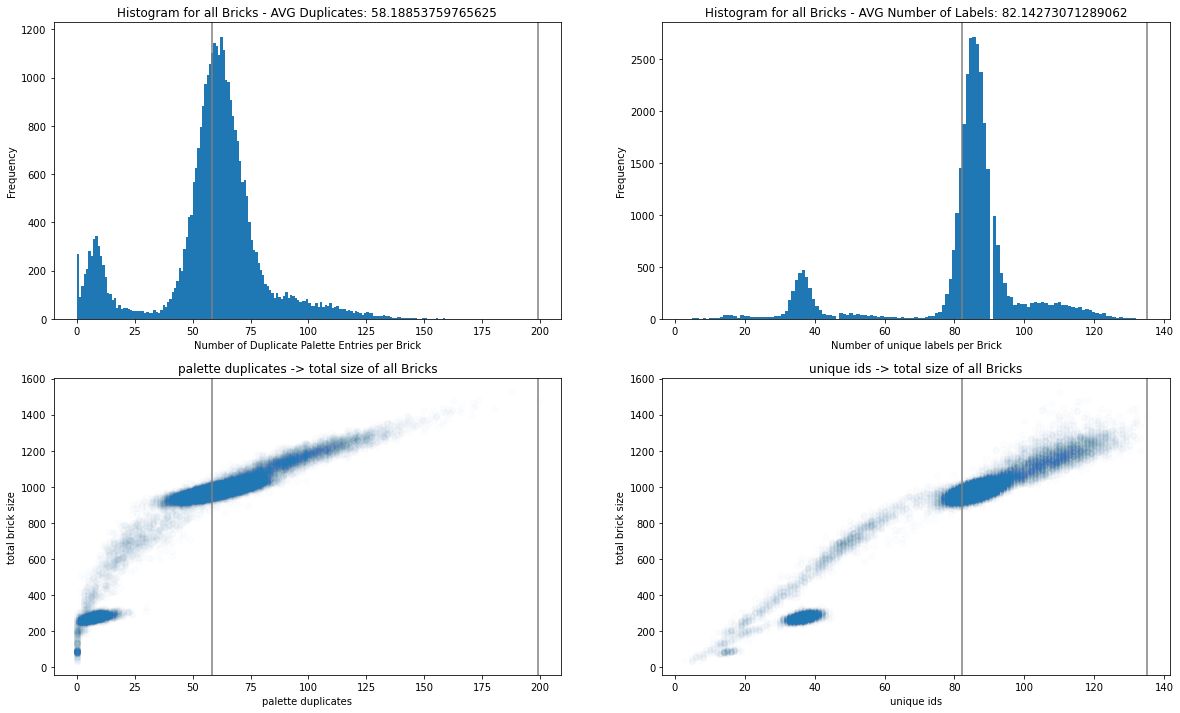

In [7]:
# add a column that should ideally be 0 everywhere: duplicate palette entries
plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 1)
plt.title("Histogram for all Bricks - AVG Duplicates: " + str(csv["palette_duplicates"].mean()))
plt.xlabel("Number of Duplicate Palette Entries per Brick")
plt.ylabel("Frequency")
plt.axvline(csv["palette_duplicates"].mean(), c='gray')
plt.axvline(csv["palette_duplicates"].max(), c='gray')
plt.hist(csv["palette_duplicates"], bins=csv["palette_duplicates"].max())

plt.subplot(2, 2, 2)
# plt.title("unique ids -> palette duplicates of all Bricks")
# plt.scatter(csv["unique_ids"], csv["palette_duplicates"], alpha=0.01)
# plt.axvline(csv["unique_ids"].mean())
# plt.axvline(csv["unique_ids"].max())
# plt.xlabel("unique ids")
# plt.ylabel("duplicate entries in palette")
plt.title("Histogram for all Bricks - AVG Number of Labels: " + str(csv["unique_ids"].mean()))
plt.xlabel("Number of unique labels per Brick")
plt.ylabel("Frequency")
plt.axvline(csv["unique_ids"].mean(), c='gray')
plt.axvline(csv["unique_ids"].max(), c='gray')
plt.hist(csv["unique_ids"], bins=csv["unique_ids"].max())

plt.subplot(2, 2, 3)
plt.title("palette duplicates -> total size of all Bricks")
plt.axvline(csv["palette_duplicates"].mean(), c='gray')
plt.axvline(csv["palette_duplicates"].max(), c='gray')
plt.scatter(csv["palette_duplicates"], csv["total_size"], alpha=0.01)
plt.xlabel("palette duplicates")
plt.ylabel("total brick size")

plt.subplot(2, 2, 4)
plt.title("unique ids -> total size of all Bricks")
plt.axvline(csv["unique_ids"].mean(), c='gray')
plt.axvline(csv["unique_ids"].max(), c='gray')
plt.scatter(csv["unique_ids"], csv["total_size"], alpha=0.01)
plt.xlabel("unique ids")
plt.ylabel("total brick size")
plt.show()

In [8]:
#VARIABLE_BIT_LENGTH_CODES = ["tPARENT", "tNEIGHBORX", "tNEIGHBORY", "tNEIGHBORZ", "tPALETTE_D", "tPALETTE_ADV", "tPALETTE_LAST", "RLE"]
#VARIABLE_BIT_LENGTH_CODES = ["sPARENT", "sNEIGHBORX", "PARENT", "sNEIGHBORY", "sNEIGHBORZ", "NEIGHBORX", "sPALETTE_D", "NEIGHBORY"]
#VARIABLE_BIT_LENGTH_CODES = ["sPARENT", "sNEIGHBORX", "RLE", "sNEIGHBORY", "PARENT", "sNEIGHBORZ", "NEIGHBORX", "sPALETTE_D"]
VARIABLE_BIT_LENGTH_CODES = ALL_CODES

code_frequencies = []
for index, name in enumerate(VARIABLE_BIT_LENGTH_CODES):
    code_frequencies.append((csv[name].sum(), name))
code_frequencies.sort(reverse=True)
print(code_frequencies)

orig_total_bits = 0
vari_total_bits = 0
bits_to_replace = ceil(log2(len(VARIABLE_BIT_LENGTH_CODES)))
for index, entry in enumerate(code_frequencies):
    vari_total_bits += entry[0] * (index + 1)
    orig_total_bits += entry[0] * bits_to_replace

print("original compression rate: " + str(csv["total_size"].sum() / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.) + "%")

# compute rice coding memory reduction (3 bit to variable bit length)
#vari_total_bits = csv["PARENT"].sum() * 1 + csv["NEIGHBORX"].sum() * 2 + csv["RLE"].sum() * 3 + csv["NEIGHBORY"].sum() * 4 + csv["NEIGHBORZ"].sum() * 5 + csv["PALETTE_D"].sum() * 6 + csv["PALETTE_LAST"].sum() * 7 + csv["PALETTE_ADV"].sum() * 8
#orig_total_bits = csv["PARENT"].sum() * 3 + csv["NEIGHBORX"].sum() * 3 + csv["RLE"].sum() * 3 + csv["NEIGHBORY"].sum() * 3 + csv["NEIGHBORZ"].sum() * 3 + csv["PALETTE_D"].sum() * 3 + csv["PALETTE_LAST"].sum() * 3 + csv["PALETTE_ADV"].sum() * 3

saved_bytes = int((orig_total_bits - vari_total_bits) / 8)
print("would save " + str(saved_bytes) + " bytes from total size by replacing " + str(bits_to_replace) + " bits")
print("reducing total size from " + str(csv["total_size"].sum()) + " to " + str(csv["total_size"].sum() - (saved_bytes / 4)) + " uints")
print("new compression rate approx. " + str((csv["total_size"].sum() - (saved_bytes / 4)) / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.) + "%")

print("encoding 4 bit sum actually " + str(csv["operation_count"].sum()) + " but computed " + str(orig_total_bits/3))

[(279211314, 'PARENT'), (89253318, 'NEIGHBORX'), (47244145, 'sPARENT'), (36327602, 'NEIGHBORY'), (14242668, 'NEIGHBORZ'), (6417840, 'sNEIGHBORX'), (4456412, 'PALETTE_ADV'), (2554331, 'sNEIGHBORY'), (1873869, 'PALETTE_LAST'), (1409622, 'PALETTE_D'), (934118, 'sNEIGHBORZ'), (248541, 'sPALETTE_LAST'), (141963, 'sPALETTE_ADV'), (75107, 'sPALETTE_D')]
original compression rate: 3.0159350000000003%
would save 123042105 bytes from total size by replacing 4 bits
reducing total size from 30159350 to -601176.25 uints
new compression rate approx. -0.060117625%
encoding 4 bit sum actually 484390850 but computed 645854466.6666666


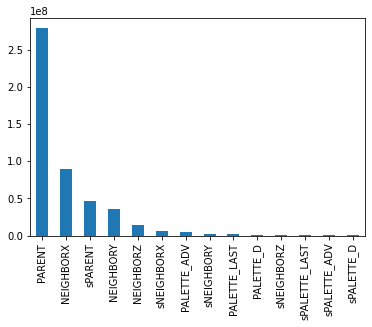

In [9]:
# show the frequencies of all encoding codes
plt.cla()
code_sums = csv[ALL_CODES].sum()
code_sums = code_sums.sort_values(ascending=False)
#print(code_sums)
code_sums.plot.bar()
plt.show()

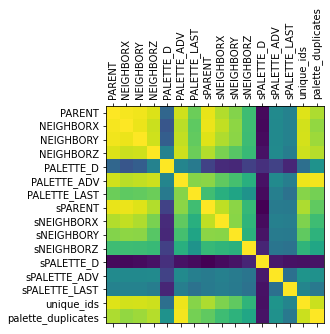

In [10]:
# we can look at correlations between the different properties
subset = csv[ALL_CODES + ["unique_ids", "palette_duplicates"]]
ax = plt.gca()
ax.matshow(subset.corr())
ax.xaxis.set_ticks(range(0, len(subset.columns)))
ax.set_xticklabels(subset.columns, rotation=90)
ax.yaxis.set_ticks(range(0, len(subset.columns)))
ax.set_yticklabels(subset.columns)
plt.show()

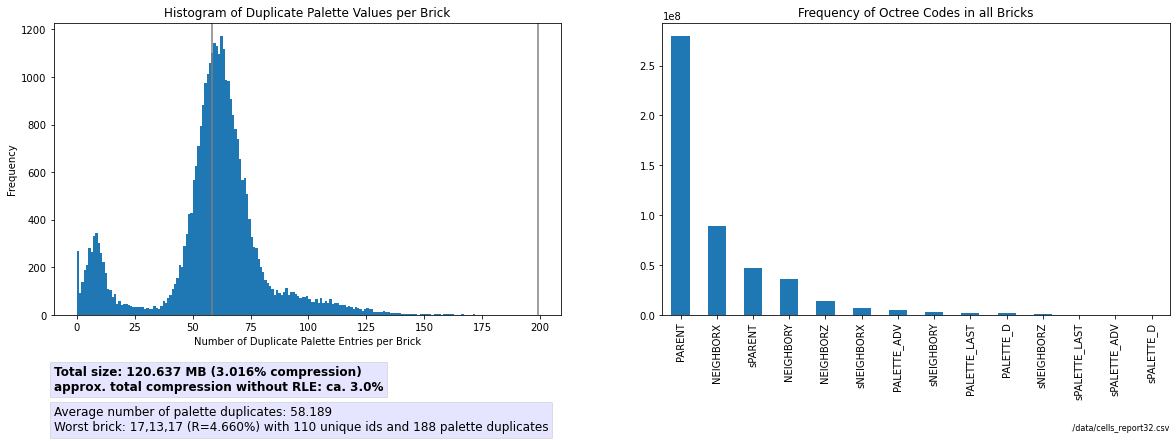

In [11]:
# a wrapup figure for the .tex reports
# TODO: make this a function that gets a path and creates the figure, then call this function for all *brickstats_*.csv files in a folder

def getHistBins(column):
    return min(csv[column].max(), csv[column].shape[0])

plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
plt.title("Histogram of Duplicate Palette Values per Brick")
plt.xlabel("Number of Duplicate Palette Entries per Brick")
plt.ylabel("Frequency")
plt.hist(csv["palette_duplicates"], bins=getHistBins("palette_duplicates"))
plt.axvline(csv["palette_duplicates"].mean(), c='gray')
plt.axvline(csv["palette_duplicates"].max(), c='gray')
#plt.hist(csv["total_size"], bins=csv["total_size"].max())
#plt.axvline(csv["total_size"].mean(), c='orange')
#plt.axvline(csv["total_size"].max(), c='orange')

plt.subplot(1, 2, 2)
plt.title("Frequency of Octree Codes in all Bricks")
code_sums.plot.bar()

worst_row_id = csv["total_size"].idxmax()
plt.gcf().text(0.125, 0.15, "Total size: " + f'{(csv["total_size"].sum() * 4 / 1000 / 1000):.3f}' + " MB (" + f'{(csv["total_size"].sum() / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.):.3f}' + "% compression)\n\
approx. total compression without RLE: ca. " + f'{(rle_size / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.):.1f}' + "%",
bbox=dict(facecolor='blue', alpha=0.1), fontsize=12, fontweight='bold')

#Total size without RLE ca" + f'{(rle_size * 4 / 1000 / 1000):.3f}' + " MB (" + f'{(rle_size / (original_dim[0] * original_dim[1] * original_dim[2]) * 100.):.3f}' + "% compression)",

plt.gcf().text(0.125, 0.07, "Average number of palette duplicates: " + f'{(csv["palette_duplicates"].mean()):.3f}' + "\n\
Worst brick: " + str(csv["brick_x"][worst_row_id]) + "," + str(csv["brick_y"][worst_row_id]) + "," + str(csv["brick_z"][worst_row_id]) + " (R=" + f'{(csv["total_size"].max()/(BRICK_SIZE**3) * 100.):.3f}' + "%) with " + str(csv["unique_ids"][worst_row_id]) + " unique ids and " + str(csv["palette_duplicates"][worst_row_id]) + " palette duplicates",
bbox=dict(facecolor='blue', alpha=0.1), fontsize=12)

plt.gcf().text(0.9, 0.07, PATH, fontsize=8, ha='right')

plt.subplots_adjust(bottom=0.3)

plt.savefig(PATH + '_report.pdf') 
plt.show()


16 bits required per entry to store 314 indices at max per brick


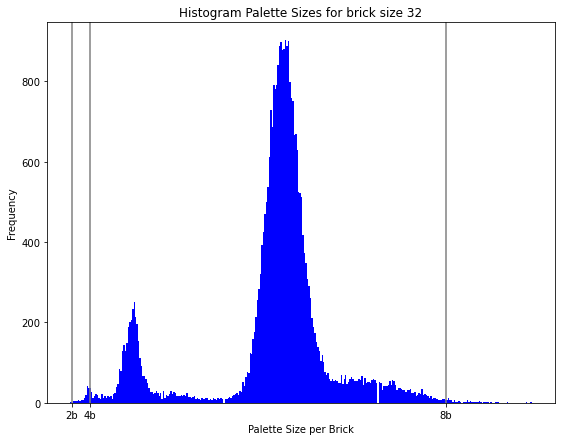

In [12]:
plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
plt.title("Histogram Palette Sizes for brick size " + str(BRICK_SIZE))
plt.xlabel("Palette Size per Brick")
plt.ylabel("Frequency")
max_power_of_two = 0
xtick_labels = []
for i in range(1, 6):
    if 2 ** (2 ** (i)) <= csv["palette_size"].max():
        plt.axvline(2 ** (2 ** i), c='gray')
        xtick_labels.append(2**i)
    if csv["palette_size"].max() >= 2 ** (2 ** (i - 1)):
        max_power_of_two = 2 ** i
print(str(max_power_of_two) + " bits required per entry to store " + str(csv["palette_size"].max()) + " indices at max per brick")
plt.hist(csv["palette_size"], bins=getHistBins("palette_size"), color='blue')
plt.xticks([2 ** x for x in xtick_labels], [str(x) + "b" for x in xtick_labels])
plt.show()